# Regularized Regression and Model Selection

We use the ISLP `Credit` and `Hitters` data to study collinearity, ridge shrinkage, lasso sparsity, cross-validation, and one final test evaluation. Ridge and lasso are implemented directly before the corresponding library pipelines.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/04-regularized-regression/'
for _name in ['Advertising.csv', 'Credit.csv', 'Hitters.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 26505
rng = np.random.default_rng(SEED)

credit = pd.read_csv('Credit.csv')
hitters = pd.read_csv('Hitters.csv').dropna().reset_index(drop=True)
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331


## 1. Collinearity in the Credit data

In [2]:
credit_features = ["Income", "Limit", "Rating", "Cards", "Age", "Education"]
X_credit_raw = credit[credit_features].to_numpy(float)
y_credit_raw = credit["Balance"].to_numpy(float)

def fit_standardizer(X):
    mean = X.mean(axis=0)
    scale = X.std(axis=0)
    return mean, scale

def apply_standardizer(X, mean, scale):
    return (X - mean) / scale

mean_credit, scale_credit = fit_standardizer(X_credit_raw)
X_credit = apply_standardizer(X_credit_raw, mean_credit, scale_credit)
y_credit = y_credit_raw - y_credit_raw.mean()

print("Limit/Rating correlation:", credit[["Limit", "Rating"]].corr().iloc[0, 1])
print("condition number of standardized X'X:", np.linalg.cond(X_credit.T @ X_credit))

Limit/Rating correlation: 0.9968797370016825
condition number of standardized X'X: 1262.2123850499909


## 2. Ridge regression from scratch

In [3]:
def ridge_closed_form(X, y, alpha):
    # Minimizes 0.5*||y-Xb||^2 + 0.5*alpha*||b||^2.
    return np.linalg.solve(X.T @ X + alpha * np.eye(X.shape[1]), X.T @ y)

for alpha in [0, 10, 80, 400]:
    if alpha == 0:
        beta = np.linalg.lstsq(X_credit, y_credit, rcond=None)[0]
    else:
        beta = ridge_closed_form(X_credit, y_credit, alpha)
    print(f"alpha={alpha:>3}: ||beta||={np.linalg.norm(beta):8.3f}, "
          f"Limit={beta[1]:8.3f}, Rating={beta[2]:8.3f}")

alpha=  0: ||beta||= 507.071, Limit= 290.126, Rating= 318.812
alpha= 10: ||beta||= 470.968, Limit= 287.674, Rating= 288.991
alpha= 80: ||beta||= 332.726, Limit= 220.890, Rating= 220.887
alpha=400: ||beta||= 187.230, Limit= 131.393, Rating= 131.635


In [4]:
# Verify the direct solution against scikit-learn only after implementing it.
from sklearn.linear_model import Ridge

alpha = 80
direct = ridge_closed_form(X_credit, y_credit, alpha)
library = Ridge(alpha=alpha, fit_intercept=False).fit(X_credit, y_credit).coef_
print("maximum absolute difference:", np.max(np.abs(direct - library)))
assert np.allclose(direct, library)

maximum absolute difference: 1.7053025658242404e-13


## 3. Lasso and soft thresholding from scratch

In [5]:
def soft_threshold(value, threshold):
    return np.sign(value) * np.maximum(np.abs(value) - threshold, 0.0)

z = np.array([-2.0, -0.7, 0.2, 1.4])
print("z:     ", z)
print("S_1(z):", soft_threshold(z, 1.0))

z:      [-2.  -0.7  0.2  1.4]
S_1(z): [-1.  -0.   0.   0.4]


In [6]:
def lasso_coordinate_descent(X, y, penalty, max_sweeps=20_000, tolerance=1e-10):
    # X columns are centered and scaled so ||x_j||^2/n = 1.
    n, p = X.shape
    beta = np.zeros(p)
    for sweep in range(max_sweeps):
        previous = beta.copy()
        for j in range(p):
            partial_residual = y - X @ beta + X[:, j] * beta[j]
            unregularized_coordinate = X[:, j] @ partial_residual / n
            beta[j] = soft_threshold(unregularized_coordinate, penalty)
        if np.max(np.abs(beta - previous)) < tolerance:
            return beta, sweep + 1
    raise RuntimeError("coordinate descent did not converge")

penalty = 0.08
beta_lasso, sweeps = lasso_coordinate_descent(X_credit, y_credit, penalty)
pd.Series(beta_lasso, index=credit_features).to_frame("from_scratch").assign(sweeps=sweeps)

,from_scratch,sweeps
Income,-265.684731,5343
Limit,289.365450,5343
Rating,319.202530,5343
Cards,15.782280,5343
Age,-15.316716,5343
Education,6.156079,5343


In [7]:
from sklearn.linear_model import Lasso

library_lasso = Lasso(alpha=penalty, fit_intercept=False, max_iter=100_000, tol=1e-10)     .fit(X_credit, y_credit).coef_
comparison = pd.DataFrame({
    "from_scratch": beta_lasso,
    "library": library_lasso,
    "absolute_difference": np.abs(beta_lasso - library_lasso),
}, index=credit_features)
comparison

,from_scratch,library,absolute_difference
Income,-265.684731,-265.684731,1.307910e-08
Limit,289.365450,289.365457,7.239747e-06
Rating,319.202530,319.202523,7.224692e-06
Cards,15.782280,15.782280,3.085136e-07
Age,-15.316716,-15.316716,4.091124e-09
Education,6.156079,6.156079,3.185199e-08


## 4. Choosing the penalty by five-fold cross-validation

In [8]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

# Numeric columns only: the deck uses 16 plain counting statistics, since the
# one-hot encoding added complexity without teaching anything.
numeric = [c for c in hitters.columns if hitters[c].dtype != object and c != "Salary"]
X_hitters = hitters[numeric].astype(float)
y_hitters = np.log(hitters["Salary"].to_numpy(float))
print("features:", len(numeric))
train_index, test_index = train_test_split(
    np.arange(len(hitters)), test_size=0.25, random_state=SEED
)
X_train, X_test = X_hitters.iloc[train_index], X_hitters.iloc[test_index]
y_train, y_test = y_hitters[train_index], y_hitters[test_index]
folds = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(X_train))

def validation_curve(model_name, alphas):
    fold_errors = []
    for alpha in alphas:
        errors = []
        for fit_index, validation_index in folds:
            estimator = (Ridge(alpha=alpha) if model_name == "ridge"
                         else Lasso(alpha=alpha, max_iter=100_000))
            pipeline = make_pipeline(StandardScaler(), estimator)
            pipeline.fit(X_train.iloc[fit_index], y_train[fit_index])
            prediction = pipeline.predict(X_train.iloc[validation_index])
            errors.append(mean_squared_error(y_train[validation_index], prediction) ** 0.5)
        fold_errors.append(errors)
    fold_errors = np.asarray(fold_errors)
    mean = fold_errors.mean(axis=1)
    se = fold_errors.std(axis=1, ddof=1) / np.sqrt(fold_errors.shape[1])
    minimum = int(np.argmin(mean))
    return pd.DataFrame({"alpha": alphas, "mean_rmse": mean, "se": se}), minimum

ridge_curve, ridge_min = validation_curve("ridge", np.logspace(-2, 3, 48))
lasso_curve, lasso_min = validation_curve("lasso", np.logspace(-4, -0.4, 48))

# ISL 6.2.3: select the penalty with the smallest cross-validation error.
print("ridge:", ridge_curve.iloc[ridge_min].round(4).to_dict())
print("lasso:", lasso_curve.iloc[lasso_min].round(4).to_dict())

features: 16


ridge: {'alpha': 25.3662, 'mean_rmse': 0.6392, 'se': 0.0354}
lasso: {'alpha': 0.0283, 'mean_rmse': 0.6382, 'se': 0.035}


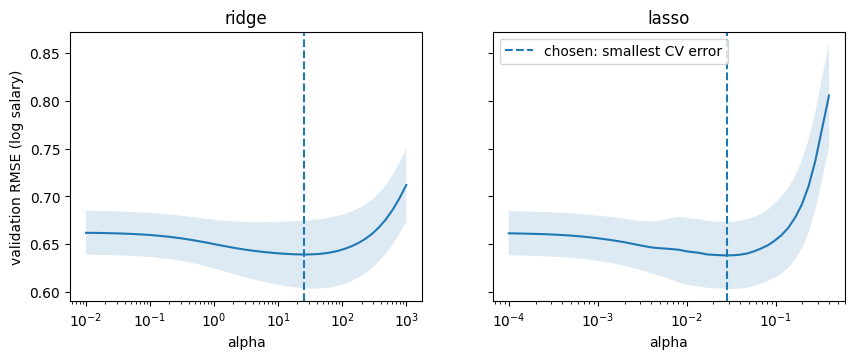

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, curve, minimum, name in [
    (axes[0], ridge_curve, ridge_min, "ridge"),
    (axes[1], lasso_curve, lasso_min, "lasso"),
]:
    ax.plot(curve.alpha, curve.mean_rmse)
    ax.fill_between(curve.alpha, curve.mean_rmse-curve.se, curve.mean_rmse+curve.se, alpha=.15)
    ax.axvline(curve.alpha.iloc[minimum], linestyle="--", label="chosen: smallest CV error")
    ax.set_xscale("log"); ax.set_title(name); ax.set_xlabel("alpha")
axes[0].set_ylabel("validation RMSE (log salary)")
axes[1].legend();

The dip is shallow: a wide range of penalties gives almost the same error, and the shaded band shows the spread across the five folds.

## 5. One final test evaluation

In [10]:
ridge_alpha = ridge_curve.alpha.iloc[ridge_min]
lasso_alpha = lasso_curve.alpha.iloc[lasso_min]
models = {
    "least squares": make_pipeline(StandardScaler(), LinearRegression()),
    "ridge": make_pipeline(StandardScaler(), Ridge(alpha=ridge_alpha)),
    "lasso": make_pipeline(StandardScaler(), Lasso(alpha=lasso_alpha, max_iter=100_000)),
}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    rmse = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
    nonzero = np.nan if name != "lasso" else np.count_nonzero(model[-1].coef_)
    rows.append({"model": name, "test_rmse": rmse, "nonzero_coefficients": nonzero})
pd.DataFrame(rows).round(4)

,model,test_rmse,nonzero_coefficients
0,least squares,0.6658,NaN
1,ridge,0.6396,NaN
2,lasso,0.6310,7.0


## Try It

1. Repeat the train/test split over 50 seeds. How variable is the apparent ranking of least squares, ridge, and lasso?
2. Replace log salary by salary. Which observations dominate squared error?
3. Which features does the lasso keep? Compare them with the largest ridge coefficients.
4. Report predictive performance, coefficient stability, and sparsity as three separate outcomes.

## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [11]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '04-regularized-regression'
NOTES = COURSE / 'lectures' / 'figures'

### `make_computation_figures.py`

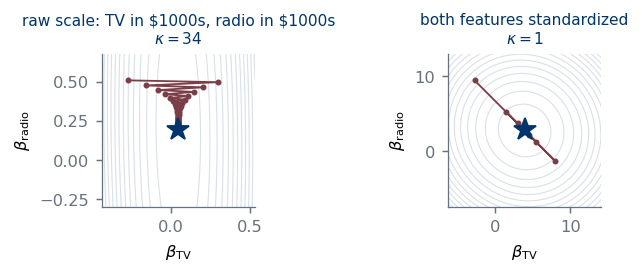

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/04-regularized-regression/gd-path.pdf')

In [12]:
from __future__ import annotations


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


_COST: dict = {}

NOTES = OUT.parents[2] / "lectures" / "figures"


def notes_svg(name: str) -> Path:
    return NOTES / f"ch05-{name}.svg"


ad = pd.read_csv('Advertising.csv', index_col=0)
tv, radio, news, sales = ad.TV.values, ad.radio.values, ad.newspaper.values, ad.sales.values
ones = np.ones_like(tv)


def _centred_two_feature(scaled: bool):
    """sales on TV and radio, both centred; optionally scaled to unit variance.

    TV has standard deviation 85.9 and radio 14.9, so on the raw scale the two
    coordinates of the loss are stretched by roughly (85.9/14.9)^2 ~ 33.  That
    is real, visible anisotropy from real data, not a contrived example.
    """
    a = tv - tv.mean()
    b = radio - radio.mean()
    if scaled:
        a, b = a / tv.std(), b / radio.std()
    return np.c_[a, b], sales - sales.mean()



def _gd(X, y, lr, steps, start=(0.0, 0.0)):
    n = len(y)
    theta = np.array(start, float)
    path = [theta.copy()]
    for _ in range(steps):
        grad = X.T @ (X @ theta - y) / n
        theta = theta - lr * grad
        path.append(theta.copy())
    return np.array(path)



def fig_gd_path():
    """Gradient descent zigzags when the two features are on different scales."""
    fig, axes = plt.subplots(1, 2, figsize=FULL)

    for ax, scaled, title in [
        (axes[0], False, "raw scale: TV in \\$1000s, radio in \\$1000s"),
        (axes[1], True, "both features standardized"),
    ]:
        X, y = _centred_two_feature(scaled)
        best, *_ = np.linalg.lstsq(X, y, rcond=None)
        lam = np.linalg.eigvalsh(X.T @ X / len(y))
        kappa = lam.max() / lam.min()
        lr = 1.8 / lam.max()

        r0 = 2.6 * np.abs(best).max()
        g0 = np.linspace(best[0] - r0, best[0] + r0, 160)
        g1 = np.linspace(best[1] - r0, best[1] + r0, 160)
        G0, G1 = np.meshgrid(g0, g1)
        resid = y[:, None, None] - G0[None] * X[:, 0][:, None, None] - G1[None] * X[:, 1][:, None, None]
        R = (resid**2).mean(axis=0)

        ax.contour(G0, G1, R, levels=16, colors=RULE, linewidths=0.6)
        path = _gd(X, y, lr, 60, start=(best[0] - 1.7 * r0 / 2.6, best[1] + 1.7 * r0 / 2.6))
        ax.plot(path[:, 0], path[:, 1], "-o", ms=2.3, lw=1.0, color=RED, zorder=4)
        ax.plot(*best, marker="*", ms=13, color=BLUE, zorder=5)
        ax.set_aspect("equal")
        ax.set_xlabel(r"$\beta_{\mathrm{TV}}$")
        ax.set_ylabel(r"$\beta_{\mathrm{radio}}$")
        ax.set_title(f"{title}\n" + rf"$\kappa = {kappa:.0f}$", fontsize=8.5)
    fig.tight_layout(pad=0.35)
    return save(fig, OUT / "gd-path.pdf", notes_svg("gd-path"))

fig_gd_path()

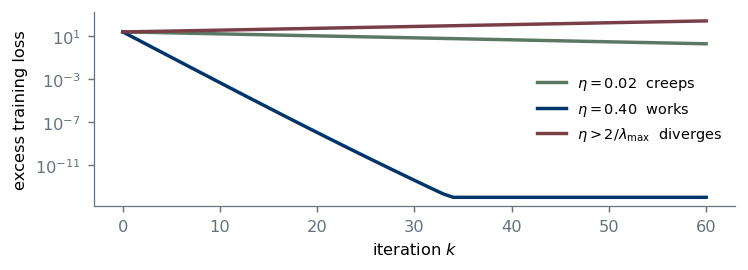

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/04-regularized-regression/gd-learning-rate.pdf')

In [13]:
def fig_gd_learning_rate():
    """The learning rate, on the standardized Advertising problem."""
    X, y = _centred_two_feature(scaled=True)
    best, *_ = np.linalg.lstsq(X, y, rcond=None)
    rbest = y - X @ best
    floor = rbest @ rbest / len(y)
    lam_max = np.linalg.eigvalsh(X.T @ X / len(y)).max()

    fig, ax = plt.subplots(figsize=FULL)
    runs = [
        (0.02, GREEN, r"$\eta = 0.02$  creeps"),
        (0.40, BLUE, r"$\eta = 0.40$  works"),
        (2.02 / lam_max, RED, r"$\eta > 2/\lambda_{\max}$  diverges"),
    ]
    for lr, color, label in runs:
        path = _gd(X, y, lr, 60, start=(0.0, 0.0))
        pred = path @ X.T
        curve = ((y[None] - pred) ** 2).mean(axis=1) - floor
        ax.semilogy(np.arange(len(curve)), np.maximum(curve, 1e-14), color=color,
                    lw=1.9, label=label)
    ax.set_xlabel("iteration $k$")
    ax.set_ylabel(r"excess training loss")
    ax.legend(loc="center right", fontsize=8.0)
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "gd-learning-rate.pdf", notes_svg("gd-learning-rate"))

fig_gd_learning_rate()

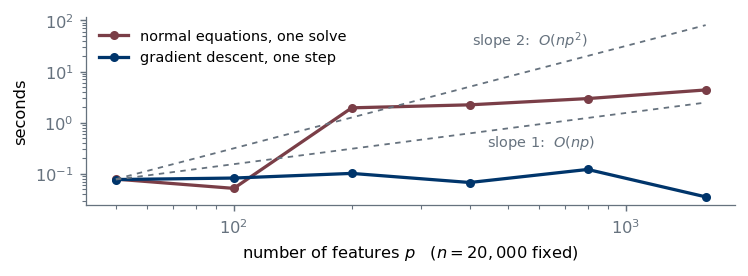

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/04-regularized-regression/cost-scaling.pdf')

In [14]:
def fig_cost_scaling():
    """Measured wall-clock cost: the closed form versus gradient descent.

    This is the concrete evidence behind the O(np^2 + p^3) versus O(np) count.
    Timings are measured on this machine at figure-build time and printed by
    report(), so the slide can quote what was actually observed.
    """
    import time

    rng = np.random.default_rng(0)
    n = 20_000
    ps = [50, 100, 200, 400, 800, 1600]
    exact, grad = [], []
    for p in ps:
        Xd = rng.normal(size=(n, p))
        yd = rng.normal(size=n)

        t0 = time.perf_counter()
        for _ in range(3):
            np.linalg.solve(Xd.T @ Xd, Xd.T @ yd)
        exact.append((time.perf_counter() - t0) / 3)

        theta = np.zeros(p)
        t0 = time.perf_counter()
        for _ in range(50):
            theta -= 1e-5 * (Xd.T @ (Xd @ theta - yd) / n)
        grad.append((time.perf_counter() - t0) / 50)

    fig, ax = plt.subplots(figsize=FULL)
    ax.loglog(ps, exact, "-o", ms=4, color=RED, label=r"normal equations, one solve")
    ax.loglog(ps, grad, "-o", ms=4, color=BLUE, label=r"gradient descent, one step")
    ref = np.array(ps, float)
    ax.loglog(ref, exact[0] * (ref / ref[0]) ** 2, ls=(0, (3, 3)), lw=1.0, color=MUTED)
    ax.annotate(r"slope $2$:  $O(np^2)$", xy=(ps[-2], exact[0] * (ps[-2] / ps[0]) ** 2),
                xytext=(-64, 6), textcoords="offset points", color=MUTED, fontsize=8.0)
    ax.loglog(ref, grad[0] * (ref / ref[0]), ls=(0, (3, 3)), lw=1.0, color=MUTED)
    ax.annotate(r"slope $1$:  $O(np)$", xy=(ps[-2], grad[0] * (ps[-2] / ps[0])),
                xytext=(-56, -16), textcoords="offset points", color=MUTED, fontsize=8.0)
    ax.set_xlabel(f"number of features $p$   ($n = {n:,}$ fixed)")
    ax.set_ylabel("seconds")
    ax.legend(loc="upper left", fontsize=8.0)
    fig.tight_layout(pad=0.3)
    _COST.update({"n": n, "ps": ps, "exact": exact, "grad": grad})
    return save(fig, OUT / "cost-scaling.pdf", notes_svg("cost-scaling"))

fig_cost_scaling()

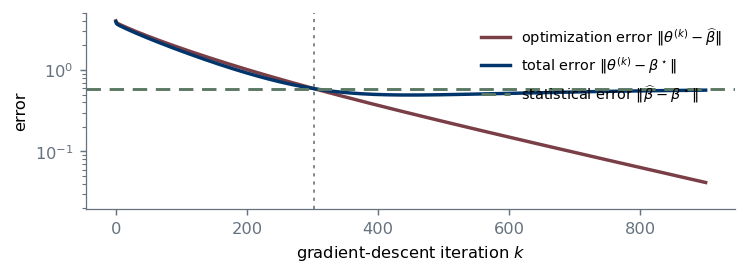

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/04-regularized-regression/error-decomposition.pdf')

In [15]:
def fig_error_decomposition():
    """Zhaoran's argument: the statistical error is a floor GD cannot cross."""
    rng = np.random.default_rng(265)
    n, p, sigma = 400, 20, 1.0
    # Correlated features, so gradient descent takes a realistic number of
    # steps instead of converging before the plot can show anything.
    idx = np.arange(p)
    corr = 0.9 ** np.abs(idx[:, None] - idx[None, :])
    Xd = rng.normal(size=(n, p)) @ np.linalg.cholesky(corr).T
    theta_true = rng.normal(size=p)
    yd = Xd @ theta_true + sigma * rng.normal(size=n)

    theta_ls, *_ = np.linalg.lstsq(Xd, yd, rcond=None)
    stat_err = float(np.linalg.norm(theta_ls - theta_true))

    lr = 1.0 / np.linalg.eigvalsh(Xd.T @ Xd / n).max()
    path = _gd(Xd, yd, lr, 900, start=tuple(np.zeros(p)))
    opt = np.linalg.norm(path - theta_ls, axis=1)
    total = np.linalg.norm(path - theta_true, axis=1)
    it = np.arange(len(path))

    fig, ax = plt.subplots(figsize=FULL)
    ax.semilogy(it, opt, color=RED, lw=1.9,
                label=r"optimization error $\|\theta^{(k)}-\widehat{\beta}\|$")
    ax.semilogy(it, total, color=BLUE, lw=1.9,
                label=r"total error $\|\theta^{(k)}-\beta^\star\|$")
    ax.axhline(stat_err, color=GREEN, lw=1.6, ls=(0, (5, 3)),
               label=r"statistical error $\|\widehat{\beta}-\beta^\star\|$")
    cross = int(np.argmax(opt < stat_err))
    ax.axvline(cross, color=MUTED, lw=0.9, ls=(0, (2, 3)))
    ax.annotate(
        f"past $k\\approx{cross}$, further\noptimization buys nothing",
        xy=(cross, stat_err * 14), xytext=(14, 0), textcoords="offset points",
        color=MUTED, fontsize=8,
    )
    ax.set_xlabel("gradient-descent iteration $k$")
    ax.set_ylabel("error")
    ax.set_ylim(stat_err / 30, None)
    ax.legend(loc="upper right", fontsize=8.0)
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "error-decomposition.pdf", notes_svg("error-decomposition"))

fig_error_decomposition()

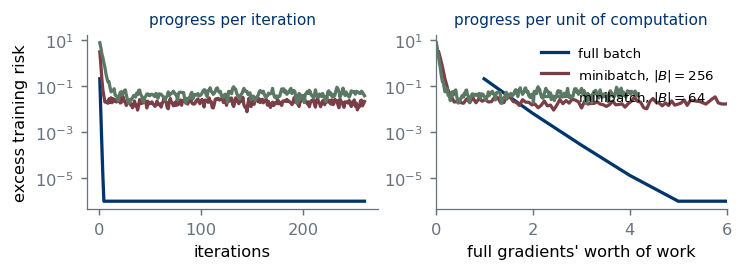

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/04-regularized-regression/minibatch.pdf')

In [16]:
def report():
    if _COST:
        print(f"timing  n={_COST['n']:,}")
        for p_, e, g in zip(_COST["ps"], _COST["exact"], _COST["grad"]):
            print(f"           p={p_:5d}  exact {e*1000:9.2f} ms   one GD step {g*1000:7.3f} ms"
                  f"   ratio {e/g:8.1f}")



# --- Minibatch SGD: cheaper, noisier steps ---------------------------------
def fig_minibatch():
    """Full-batch gradient descent against minibatch SGD on the same problem."""
    rng = np.random.default_rng(265)
    n, p = 4000, 20
    Xd = rng.normal(size=(n, p))
    yd = Xd @ rng.normal(size=p) + rng.normal(size=n)
    best, *_ = np.linalg.lstsq(Xd, yd, rcond=None)
    floor = ((yd - Xd @ best) ** 2).mean()
    # Hessian of (1/n)||y - Xb||^2 is (2/n)X'X, so eta < 1/lambda_max(X'X/n).
    lmax = np.linalg.eigvalsh(Xd.T @ Xd / n).max()
    lr = 0.5 / lmax

    def run(bs, eta, steps=260):
        beta = np.zeros(p)
        loss, work = [], []
        for k in range(steps):
            idx = rng.integers(0, n, bs) if bs < n else slice(None)
            Xb, yb = Xd[idx], yd[idx]
            beta = beta - eta * (2.0 / len(yb)) * Xb.T @ (Xb @ beta - yb)
            loss.append(max(((yd - Xd @ beta) ** 2).mean() - floor, 1e-6))
            work.append((k + 1) * (bs / n))
        return np.array(loss), np.array(work)

    runs = [(n, lr, BLUE, "full batch"),
            (256, 0.5 * lr, RED, r"minibatch, $|B|=256$"),
            (64, 0.3 * lr, GREEN, r"minibatch, $|B|=64$")]

    fig, axes = plt.subplots(1, 2, figsize=FULL)
    for bs, eta, colour, label in runs:
        loss, work = run(bs, eta)
        axes[0].semilogy(np.arange(1, len(loss) + 1), loss, color=colour, lw=1.8, label=label)
        axes[1].semilogy(work, loss, color=colour, lw=1.8, label=label)
    axes[0].set_xlabel("iterations")
    axes[0].set_ylabel("excess training risk")
    axes[0].set_title("progress per iteration", fontsize=8.5)
    axes[1].set_xlabel("full gradients' worth of work")
    axes[1].set_xlim(0, 6)
    axes[1].set_title("progress per unit of computation", fontsize=8.5)
    axes[1].legend(loc="upper right", fontsize=7.4)
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "minibatch.pdf", notes_svg("minibatch"))

fig_minibatch()

### `make_regularization_figures.py`

In [17]:
from __future__ import annotations


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Polygon, Rectangle
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 26505
rng = np.random.default_rng(SEED)

credit = pd.read_csv('Credit.csv')
credit_X = pd.get_dummies(credit.drop(columns="Balance"), drop_first=True, dtype=float)
credit_y = credit["Balance"].to_numpy(float)
# Credit carries the instability / ridge / lasso story. Hitters is used only for
# cross-validation, where we need a case in which the lasso genuinely selects.
# Numeric columns only: the one-hot encoding added complexity without teaching
# anything, so the design is 16 plain season and career statistics.
hitters = pd.read_csv('Hitters.csv').dropna().reset_index(drop=True)
_hit_num = [c for c in hitters.columns
            if hitters[c].dtype != object and c != "Salary"]
hitters_X = hitters[_hit_num].astype(float)
hitters_y = np.log(hitters["Salary"].to_numpy(float))


def write(fig, name):
    save(fig, OUT / f"{name}.pdf", OUT / f"{name}.svg")

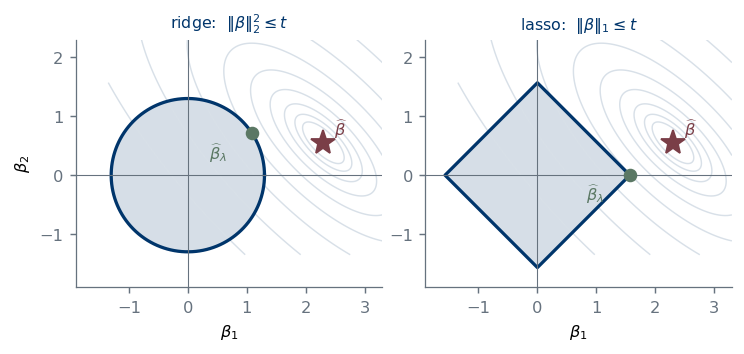

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/04-regularized-regression/constraint-geometry.pdf')

In [18]:
def standardize(matrix):
    matrix = np.asarray(matrix, float)
    return (matrix - matrix.mean(0)) / matrix.std(0)


def credit_collinearity():
    fig, ax = plt.subplots(figsize=FULL_TALL)
    points = ax.scatter(credit["Limit"], credit["Rating"], c=credit["Balance"],
                        cmap="viridis", s=20, alpha=.78, edgecolor="none")
    correlation = credit[["Limit", "Rating"]].corr().iloc[0, 1]
    ax.text(.04, .92, rf"correlation $={correlation:.3f}$", transform=ax.transAxes,
            color=INK, fontweight="bold")
    ax.set(xlabel="credit limit (dollars)", ylabel="credit rating")
    bar = fig.colorbar(points, ax=ax, pad=.02)
    bar.set_label("balance (dollars)")
    write(fig, "credit-collinearity")


def half_sample_prediction_agreement():
    """Compare two half-sample fits on the same 400 customer feature rows."""
    columns = ["Income", "Limit", "Rating", "Cards", "Age", "Education"]
    X = credit[columns].to_numpy(float)
    y = credit["Balance"].to_numpy(float)
    first, second = np.arange(200), np.arange(200, 400)

    fit_first = LinearRegression().fit(X[first], y[first])
    fit_second = LinearRegression().fit(X[second], y[second])
    pred_first = fit_first.predict(X)
    pred_second = fit_second.predict(X)
    mean_absolute_gap = np.mean(np.abs(pred_first - pred_second))
    prediction_correlation = np.corrcoef(pred_first, pred_second)[0, 1]

    fig, ax = plt.subplots(figsize=FULL_TALL)
    limits = [min(pred_first.min(), pred_second.min()),
              max(pred_first.max(), pred_second.max())]
    pad = 0.04 * (limits[1] - limits[0])
    limits = [limits[0] - pad, limits[1] + pad]
    ax.scatter(pred_first, pred_second, s=13, color=BLUE, alpha=.45,
               edgecolor="none")
    ax.plot(limits, limits, color=RED, linestyle="--", linewidth=1.5,
            label="equal predictions")
    ax.set(xlim=limits, ylim=limits,
           xlabel="prediction from first-half fit ($)",
           ylabel="prediction from second-half fit ($)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")
    ax.text(.97, .06,
            rf"correlation $={prediction_correlation:.3f}$" + "\n" +
            rf"mean $|\Delta|=${mean_absolute_gap:.0f}",
            transform=ax.transAxes, ha="right", va="bottom", color=INK,
            fontweight="bold")
    write(fig, "half-sample-prediction-agreement")


def quadratic_grid():
    b1 = np.linspace(-.4, 2.9, 250)
    b2 = np.linspace(-.8, 2.25, 250)
    B1, B2 = np.meshgrid(b1, b2)
    loss = (B1 - 2.0) ** 2 + 2.4 * (B2 - 1.0) ** 2 + .9 * (B1 - 2.0) * (B2 - 1.0)
    return B1, B2, loss


def ridge_geometry():
    B1, B2, loss = quadratic_grid()
    fig, ax = plt.subplots(figsize=FULL_TALL)
    ax.contour(B1, B2, loss, levels=[.18, .4, .8, 1.5, 2.5, 4.0], colors=RULE)
    radius = 1.18
    angle = np.linspace(0, 2 * np.pi, 400)
    ax.fill(radius * np.cos(angle), radius * np.sin(angle), color=BLUE, alpha=.08)
    ax.plot(radius * np.cos(angle), radius * np.sin(angle), color=BLUE)
    constrained = np.array([1.04, .56])
    ax.scatter([2], [1], marker="*", s=90, color=RED, label="least squares")
    ax.scatter(*constrained, s=42, color=GREEN, label="ridge solution")
    ax.set(xlabel=r"$\beta_1$", ylabel=r"$\beta_2$", xlim=(-.4, 2.9), ylim=(-.8, 2.25))
    ax.set_aspect("equal")
    ax.legend(loc="upper left")
    write(fig, "ridge-geometry")


def lasso_geometry():
    B1, B2, loss = quadratic_grid()
    fig, ax = plt.subplots(figsize=FULL_TALL)
    ax.contour(B1, B2, loss, levels=[.18, .4, .8, 1.5, 2.5, 4.0], colors=RULE)
    radius = 1.42
    diamond = np.array([[radius, 0], [0, radius], [-radius, 0], [0, -radius]])
    ax.add_patch(Polygon(diamond, closed=True, facecolor=RED, alpha=.07, edgecolor=RED))
    constrained = np.array([1.42, 0.0])
    ax.scatter([2], [1], marker="*", s=90, color=RED, label="least squares")
    ax.scatter(*constrained, s=42, color=GREEN, label="lasso solution")
    ax.set(xlabel=r"$\beta_1$", ylabel=r"$\beta_2$", xlim=(-.4, 2.9), ylim=(-.8, 2.25))
    ax.set_aspect("equal")
    ax.legend(loc="upper left")
    write(fig, "lasso-geometry")


def ridge_path():
    X = standardize(credit_X)
    y = credit_y - credit_y.mean()
    alphas = np.logspace(0, 6, 90)
    coefficients = np.vstack([Ridge(alpha=a, fit_intercept=False).fit(X, y).coef_ for a in alphas])
    importance = np.argsort(np.abs(coefficients[0]))[-6:]
    fig, ax = plt.subplots(figsize=FULL_TALL)
    ax.plot(alphas, coefficients, color=RULE, linewidth=.8)
    colors = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED, "#7A5E3A"]
    for index, color in zip(importance, colors):
        ax.plot(alphas, coefficients[:, index], color=color, linewidth=1.7,
                label=credit_X.columns[index])
    ax.set_xscale("log")
    ax.set(xlabel=r"ridge penalty $\lambda$", ylabel="standardized coefficient")
    ax.legend(ncol=2, loc="best")
    write(fig, "ridge-path")


def lasso_path():
    X = standardize(credit_X)
    y = credit_y - credit_y.mean()
    alphas = np.logspace(-1, 3, 90)
    coefficients = np.vstack([
        Lasso(alpha=a, fit_intercept=False, max_iter=100_000, tol=1e-9).fit(X, y).coef_
        for a in alphas
    ])
    importance = np.argsort(np.abs(coefficients[0]))[-6:]
    fig, ax = plt.subplots(figsize=FULL_TALL)
    ax.plot(alphas, coefficients, color=RULE, linewidth=.8)
    colors = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED, "#7A5E3A"]
    for index, color in zip(importance, colors):
        ax.plot(alphas, coefficients[:, index], color=color, linewidth=1.7,
                label=credit_X.columns[index])
    ax.set_xscale("log")
    ax.set(xlabel=r"lasso penalty $\lambda$", ylabel="standardized coefficient")
    ax.legend(ncol=2, loc="best")
    write(fig, "lasso-path")


def soft_threshold():
    z = np.linspace(-3, 3, 401)
    value = np.sign(z) * np.maximum(np.abs(z) - 1.0, 0)
    fig, ax = plt.subplots(figsize=FULL_TALL)
    ax.plot(z, z, color=MUTED, linestyle="--", label="no penalty")
    ax.plot(z, value, color=RED, label=r"$S_1(z)$")
    ax.axvspan(-1, 1, color=RED, alpha=.06)
    ax.scatter([-1, 1], [0, 0], color=RED, s=25)
    ax.set(xlabel=r"unregularized coordinate $z$", ylabel="updated coefficient",
           xlim=(-3, 3), ylim=(-3, 3))
    ax.legend(loc="upper left")
    write(fig, "soft-threshold")


def cv_folds():
    fig, ax = plt.subplots(figsize=FULL_SHORT)
    ax.axis("off")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5.3)
    for fold in range(5):
        y = 4.35 - fold * .85
        for block in range(5):
            validation = block == fold
            ax.add_patch(Rectangle((block * 1.7 + .9, y), 1.55, .55,
                                   facecolor="#F8F1F2" if validation else "#F2F6FA",
                                   edgecolor=RED if validation else BLUE, linewidth=.9))
            ax.text(block * 1.7 + 1.675, y + .275,
                    "validate" if validation else "fit", ha="center", va="center",
                    fontsize=7.6, color=RED if validation else BLUE)
        ax.text(.15, y + .275, f"fold {fold + 1}", va="center", color=INK, fontsize=8)
    ax.text(5.0, .15,
            "each row is one split: fit on the four blue blocks, score on the red one",
            ha="center", color=MUTED)
    write(fig, "cv-folds")


def cv_results():
    indices_train, indices_test = train_test_split(
        np.arange(len(hitters)), test_size=.25, random_state=SEED
    )
    X_train = hitters_X.iloc[indices_train]
    y_train = hitters_y[indices_train]
    folds = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(X_train))
    grids = {"ridge": np.logspace(-2, 3, 48), "lasso": np.logspace(-4, -.4, 48)}
    curves = {}
    choices = {}
    for name, alphas in grids.items():
        fold_errors = []
        for alpha in alphas:
            errors = []
            for fit_index, validation_index in folds:
                estimator = Ridge(alpha=alpha) if name == "ridge" else Lasso(alpha=alpha, max_iter=100_000)
                model = make_pipeline(StandardScaler(), estimator)
                model.fit(X_train.iloc[fit_index], y_train[fit_index])
                prediction = model.predict(X_train.iloc[validation_index])
                errors.append(mean_squared_error(y_train[validation_index], prediction) ** .5)
            fold_errors.append(errors)
        fold_errors = np.asarray(fold_errors)
        mean = fold_errors.mean(1)
        se = fold_errors.std(1, ddof=1) / np.sqrt(fold_errors.shape[1])
        minimum = int(np.argmin(mean))
        eligible = np.where(mean <= mean[minimum] + se[minimum])[0]
        one_se = int(eligible[-1])
        curves[name] = (alphas, mean, se)
        choices[name] = {
            "minimum_alpha": float(alphas[minimum]),
            "one_se_alpha": float(alphas[one_se]),
            "minimum_rmse": float(mean[minimum]),
            "one_se_rmse": float(mean[one_se]),
            "minimum_se": float(se[minimum]),
            "threshold": float(mean[minimum] + se[minimum]),
            "flat_range": (float(mean.max()) - float(mean.min())),
        }

    fig, axes = plt.subplots(1, 2, figsize=FULL, sharey=True)
    for ax, (name, color) in zip(axes, [("ridge", BLUE), ("lasso", RED)]):
        alphas, mean, se = curves[name]
        ax.plot(alphas, mean, color=color)
        ax.fill_between(alphas, mean - se, mean + se, color=color, alpha=.13)
        # ISL 6.2.3 selects the lambda with the smallest cross-validation error.
        # The band is the spread of the five fold scores, shown to make the
        # flatness of the curve visible; no rule is built on it.
        ax.axvline(choices[name]["minimum_alpha"], color=GREEN, linestyle="--", linewidth=1,
                   label=r"$\lambda$ at minimum")
        ax.set_xscale("log")
        ax.set_xlabel(r"penalty $\lambda$")
        ax.set_title(name.title())
    axes[0].set_ylabel("validation RMSE (log salary)")
    axes[1].legend(loc="upper left", framealpha=0)
    fig.tight_layout(pad=0.3, w_pad=0.6)
    write(fig, "cv-curves")
    return indices_train, indices_test, choices


def resampling_stability():
    columns = ["Income", "Limit", "Rating", "Cards", "Age", "Education"]
    X0 = credit[columns].to_numpy(float)
    y0 = credit["Balance"].to_numpy(float)
    estimates = {"least squares": [], "ridge": []}
    for _ in range(160):
        index = rng.integers(0, len(credit), len(credit))
        X = standardize(X0[index])
        y = y0[index] - y0[index].mean()
        estimates["least squares"].append(np.linalg.lstsq(X, y, rcond=None)[0])
        estimates["ridge"].append(np.linalg.solve(X.T @ X + 80 * np.eye(X.shape[1]), X.T @ y))
    feature_indices = [columns.index("Limit"), columns.index("Rating")]
    data = []
    labels = []
    for method in ["least squares", "ridge"]:
        matrix = np.asarray(estimates[method])
        for index in feature_indices:
            data.append(matrix[:, index])
            labels.append(f"{method}\n{columns[index]}")
    fig, ax = plt.subplots(figsize=FULL_TALL)
    parts = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=.65, showfliers=False)
    for patch, color in zip(parts["boxes"], [RED, RED, GREEN, GREEN]):
        patch.set_facecolor(color)
        patch.set_alpha(.18)
        patch.set_edgecolor(color)
    ax.axhline(0, color=RULE, linewidth=.8)
    ax.set_ylabel("fitted coefficient")
    ax.set_title("spread of the coefficient across 160 samples of customers",
                 fontsize=8.6)
    fig.tight_layout(pad=0.3)
    write(fig, "resampling-stability")


def test_comparison(indices_train, indices_test, choices):
    X_train = hitters_X.iloc[indices_train]
    X_test = hitters_X.iloc[indices_test]
    y_train = hitters_y[indices_train]
    y_test = hitters_y[indices_test]
    models = {
        "least squares": make_pipeline(StandardScaler(), LinearRegression()),
        "ridge": make_pipeline(StandardScaler(), Ridge(alpha=choices["ridge"]["minimum_alpha"])),
        "lasso": make_pipeline(StandardScaler(), Lasso(alpha=choices["lasso"]["minimum_alpha"], max_iter=100_000)),
    }
    scores = {}
    nonzero = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        scores[name] = mean_squared_error(y_test, model.predict(X_test)) ** .5
        if name.startswith("lasso"):
            nonzero[name] = int(np.count_nonzero(model[-1].coef_))
    fig, ax = plt.subplots(figsize=FULL_TALL)
    names = list(scores)
    values = [scores[name] for name in names]
    bars = ax.bar(names, values, color=[MUTED, BLUE, RED], alpha=.82)
    ax.set_ylabel("held-out RMSE (log salary)")
    ax.set_ylim(0, max(values) * 1.25)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + .012, f"{value:.3f}",
                ha="center", color=INK)
    write(fig, "test-comparison")
    return scores, nonzero




def constraint_geometry():
    """Ridge and lasso constraint regions against the same RSS contours.

    Drawn side by side and at full size: the point is the difference in shape,
    and that the lasso's corner is what produces exact zeros.
    """
    # beta-hat chosen so the lasso solution lands on the axis corner, which is
    # the whole point of the picture: an exactly-zero coefficient.
    bhat = np.array([2.3, 0.55])
    A = np.array([[1.0, 0.72], [0.72, 1.0]])

    def rss(b1, b2):
        d = np.stack([b1 - bhat[0], b2 - bhat[1]])
        return np.einsum("i...,ij,j...->...", d, A, d)

    g = np.linspace(-1.35, 3.3, 400)
    G1, G2 = np.meshgrid(g, g)
    Z = rss(G1, G2)

    def constrained(norm, frac=0.55):
        """Boundary point minimizing RSS, for a radius that actually binds."""
        t = frac * (np.sqrt((bhat**2).sum()) if norm == "l2" else np.abs(bhat).sum())
        if norm == "l2":
            th = np.linspace(0, 2 * np.pi, 4000)
            pts = np.stack([t * np.cos(th), t * np.sin(th)])
        else:
            u = np.linspace(-t, t, 4000)
            pts = np.concatenate([np.stack([u, t - np.abs(u)]),
                                  np.stack([u, -(t - np.abs(u))])], axis=1)
        v = rss(pts[0], pts[1])
        i = int(np.argmin(v))
        return pts[:, i], t

    fig, axes = plt.subplots(1, 2, figsize=(5.63, 2.55))
    for ax, norm, title in [(axes[0], "l2", r"ridge:  $\|\beta\|_2^2\leq t$"),
                            (axes[1], "l1", r"lasso:  $\|\beta\|_1\leq t$")]:
        sol, t = constrained(norm)
        ax.contour(G1, G2, Z, levels=np.geomspace(0.06, 9.0, 9),
                   colors=RULE, linewidths=0.8)
        if norm == "l2":
            th = np.linspace(0, 2 * np.pi, 400)
            ax.fill(t * np.cos(th), t * np.sin(th), color=BLUE, alpha=0.16, zorder=1)
            ax.plot(t * np.cos(th), t * np.sin(th), color=BLUE, lw=1.8, zorder=2)
        else:
            ax.fill([t, 0, -t, 0], [0, t, 0, -t], color=BLUE, alpha=0.16, zorder=1)
            ax.plot([t, 0, -t, 0, t], [0, t, 0, -t, 0], color=BLUE, lw=1.8, zorder=2)
        ax.plot(*bhat, marker="*", ms=14, color=RED, zorder=5)
        ax.annotate(r"$\widehat\beta$", xy=bhat, xytext=(6, 4),
                    textcoords="offset points", color=RED, fontsize=9)
        ax.plot(*sol, "o", ms=6.5, color=GREEN, zorder=5)
        ax.annotate(r"$\widehat\beta_\lambda$", xy=sol, xytext=(-24, -14),
                    textcoords="offset points", color=GREEN, fontsize=9)
        ax.axhline(0, color=MUTED, lw=0.6); ax.axvline(0, color=MUTED, lw=0.6)
        ax.set_xlim(-1.9, 3.3); ax.set_ylim(-1.9, 2.3)
        ax.set_aspect("equal")
        ax.set_xlabel(r"$\beta_1$"); ax.set_title(title, fontsize=8.8)
    axes[0].set_ylabel(r"$\beta_2$")
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "constraint-geometry.pdf", OUT / "constraint-geometry.svg")

constraint_geometry()

/var/folders/dw/twkl7xz54f59zmk2mt5tr7t40000gn/T/ipykernel_84582/1443338985.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=0.3, h_pad=0.2)


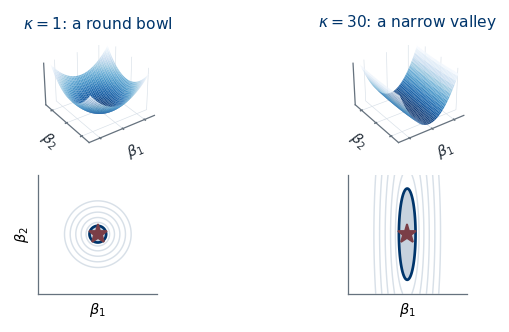

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/04-regularized-regression/conditioning-geometry.pdf')

In [19]:
def conditioning_geometry():
    """The loss surface itself, well-conditioned against a narrow valley.

    Top row: the quadratic loss as a surface. Bottom row: its level sets. The
    level sets of (b-bhat)'A(b-bhat) have semi-axes proportional to
    1/sqrt(lambda), so the valley is sqrt(kappa) times longer than it is wide.
    """
    fig = plt.figure(figsize=(5.63, 2.62))
    g = np.linspace(-3.2, 3.2, 220)
    G1, G2 = np.meshgrid(g, g)

    for col, (kappa, title) in enumerate([(1.0, r"$\kappa=1$: a round bowl"),
                                          (30.0, r"$\kappa=30$: a narrow valley")]):
        lmax, lmin = 1.0, 1.0 / kappa
        Z = lmax * G1**2 + lmin * G2**2

        ax = fig.add_subplot(2, 2, col + 1, projection="3d")
        ax.plot_surface(G1, G2, Z, cmap="Blues_r", linewidth=0, antialiased=True,
                        rstride=6, cstride=6, alpha=0.95)
        for pane in (ax.xaxis, ax.yaxis, ax.zaxis):
            pane.pane.set_alpha(0.0); pane.pane.set_edgecolor("none")
            pane._axinfo["grid"].update(color=RULE, linewidth=0.35)
        ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticks([])
        ax.tick_params(length=0)
        ax.set_xlabel(r"$\beta_1$", labelpad=-12, color=INK, fontsize=8)
        ax.set_ylabel(r"$\beta_2$", labelpad=-12, color=INK, fontsize=8)
        ax.view_init(elev=32, azim=-125)
        ax.set_box_aspect((1, 1, 0.62))
        ax.set_title(title, fontsize=8.6, pad=-2)

        ax = fig.add_subplot(2, 2, col + 3)
        eps = 0.20
        ax.contour(G1, G2, Z, levels=eps * np.array([2, 4, 7, 11, 16]),
                   colors=RULE, linewidths=0.8)
        ax.contourf(G1, G2, Z, levels=[0, eps], colors=[BLUE], alpha=0.22)
        ax.contour(G1, G2, Z, levels=[eps], colors=[BLUE], linewidths=1.5)
        ax.plot(0, 0, marker="*", ms=11, color=RED, zorder=5)
        ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(r"$\beta_1$", fontsize=8)
        if col == 0:
            ax.set_ylabel(r"$\beta_2$", fontsize=8)
    fig.tight_layout(pad=0.3, h_pad=0.2)
    return save(fig, OUT / "conditioning-geometry.pdf", OUT / "conditioning-geometry.svg")

conditioning_geometry()

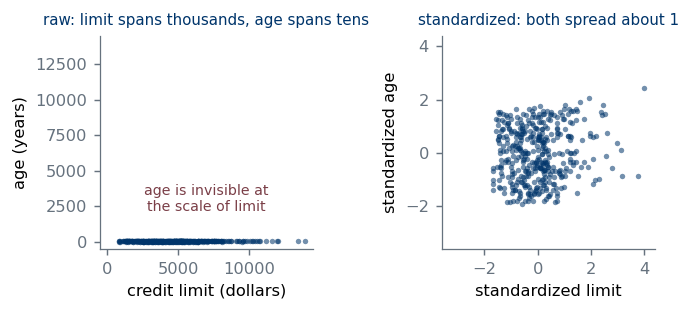

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/04-regularized-regression/standardization.pdf')

In [20]:
def standardization_effect():
    """Two Credit features before and after standardizing, on equal axes."""
    lim = credit.Limit.to_numpy(float)
    age = credit.Age.to_numpy(float)
    fig, axes = plt.subplots(1, 2, figsize=(5.63, 2.30))

    ax = axes[0]
    ax.scatter(lim, age, s=9, color=BLUE, alpha=0.55, linewidths=0)
    ax.set_xlabel("credit limit (dollars)")
    ax.set_ylabel("age (years)")
    ax.set_title("raw: limit spans thousands, age spans tens", fontsize=8.4)
    ax.set_xlim(-500, 14500); ax.set_ylim(-500, 14500)
    ax.set_aspect("equal")
    ax.annotate("age is invisible at\nthe scale of limit", xy=(7000, 2200),
                ha="center", color=RED, fontsize=7.8)

    ax = axes[1]
    zl = (lim - lim.mean()) / lim.std()
    za = (age - age.mean()) / age.std()
    ax.scatter(zl, za, s=9, color=BLUE, alpha=0.55, linewidths=0)
    ax.set_xlabel("standardized limit")
    ax.set_ylabel("standardized age")
    ax.set_title("standardized: both spread about 1", fontsize=8.4)
    ax.set_xlim(-3.6, 4.4); ax.set_ylim(-3.6, 4.4)
    ax.set_aspect("equal")
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "standardization.pdf", OUT / "standardization.svg")

standardization_effect()